In [1]:
from google.colab import drive
drive.mount('/content/drive')

# connecting our google drive to google colab
#gcp- colab
#azure- databricks
#aws- sagemaker

Mounted at /content/drive


https://www.kaggle.com/datasets/luccagodoy/obfuscated-malware-memory-2022-cic

In [3]:
#numpy is used numerical computations
import numpy as np

#used to load the csv files
import pandas as pd

#used to plot visualization like corr plot, bar chart etc.
import seaborn as sns
import matplotlib.pyplot as plt

#This library is used to ignore warning
import warnings
warnings.filterwarnings('ignore')

In [4]:
data = pd.read_csv('/content/drive/MyDrive/dataset/Malware-Project/Obfuscated-MalMem2022.csv')

In [5]:
data.head()

,Category,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,...,svcscan.kernel_drivers,svcscan.fs_drivers,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,Class
0,Benign,45,17,10.555556,0,202.844444,1694,38.500000,9129,212.302326,...,221,26,24,116,0,121,87,0,8,Benign
1,Benign,47,19,11.531915,0,242.234043,2074,44.127660,11385,242.234043,...,222,26,24,118,0,122,87,0,8,Benign
2,Benign,40,14,14.725000,0,288.225000,1932,48.300000,11529,288.225000,...,222,26,27,118,0,120,88,0,8,Benign
3,Benign,32,13,13.500000,0,264.281250,1445,45.156250,8457,264.281250,...,222,26,27,118,0,120,88,0,8,Benign
4,Benign,42,16,11.452381,0,281.333333,2067,49.214286,11816,281.333333,...,222,26,24,118,0,124,87,0,8,Benign


In [ ]:
data.shape

(58596, 57)

In [ ]:
data.columns

Index(['Category', 'pslist.nproc', 'pslist.nppid', 'pslist.avg_threads',
       'pslist.nprocs64bit', 'pslist.avg_handlers', 'dlllist.ndlls',
       'dlllist.avg_dlls_per_proc', 'handles.nhandles',
       'handles.avg_handles_per_proc', 'handles.nport', 'handles.nfile',
       'handles.nevent', 'handles.ndesktop', 'handles.nkey', 'handles.nthread',
       'handles.ndirectory', 'handles.nsemaphore', 'handles.ntimer',
       'handles.nsection', 'handles.nmutant', 'ldrmodules.not_in_load',
       'ldrmodules.not_in_init', 'ldrmodules.not_in_mem',
       'ldrmodules.not_in_load_avg', 'ldrmodules.not_in_init_avg',
       'ldrmodules.not_in_mem_avg', 'malfind.ninjections',
       'malfind.commitCharge', 'malfind.protection',
       'malfind.uniqueInjections', 'psxview.not_in_pslist',
       'psxview.not_in_eprocess_pool', 'psxview.not_in_ethread_pool',
       'psxview.not_in_pspcid_list', 'psxview.not_in_csrss_handles',
       'psxview.not_in_session', 'psxview.not_in_deskthrd',
       'psxv

In [ ]:
#showing the description of the dataset
data.describe().T


,count,mean,std,min,25%,50%,75%,max
pslist.nproc,58596.0,41.394771,5.777249,21.000000,40.000000,41.000000,43.000000,2.400000e+02
pslist.nppid,58596.0,14.713837,2.656748,8.000000,12.000000,15.000000,16.000000,7.200000e+01
pslist.avg_threads,58596.0,11.341655,1.588231,1.650000,9.972973,11.000000,12.861955,1.681818e+01
pslist.nprocs64bit,58596.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
pslist.avg_handlers,58596.0,247.509819,111.857790,34.962500,208.725000,243.963710,289.974322,2.484595e+04
dlllist.ndlls,58596.0,1810.805447,329.782639,670.000000,1556.000000,1735.000000,2087.000000,3.443000e+03
dlllist.avg_dlls_per_proc,58596.0,43.707806,5.742023,7.333333,38.833333,42.781524,49.605280,5.317073e+01
handles.nhandles,58596.0,10258.584221,4866.864130,3514.000000,8393.000000,9287.500000,12193.000000,1.047310e+06
handles.avg_handles_per_proc,58596.0,249.560958,145.999866,71.139241,209.648228,247.208951,291.355050,3.378419e+04
handles.nport,58596.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00


In [ ]:
data.describe(include="object")

,Category,Class
count,58596,58596
unique,28346,2
top,Benign,Benign
freq,29298,29298


In [ ]:
#checking the distribution of category columns
data["Category"].value_counts()

,count
Category,
Benign,29298
Spyware-Transponder-0d2089d42657c69731270d8bb536b3c988ebc3fd632916a726871d074175954a-6.raw,2
Spyware-Transponder-0d2089d42657c69731270d8bb536b3c988ebc3fd632916a726871d074175954a-5.raw,2
Spyware-Transponder-0d2089d42657c69731270d8bb536b3c988ebc3fd632916a726871d074175954a-4.raw,2
Spyware-Transponder-0d2089d42657c69731270d8bb536b3c988ebc3fd632916a726871d074175954a-3.raw,2
...,...
Spyware-CWS-0d1f91b2b0c62c5d213df24a265288ad05d65d96f7ffd6ee7e9b09612b687dcd-9.raw,1
Spyware-CWS-0d1f91b2b0c62c5d213df24a265288ad05d65d96f7ffd6ee7e9b09612b687dcd-8.raw,1
Spyware-CWS-0d1f91b2b0c62c5d213df24a265288ad05d65d96f7ffd6ee7e9b09612b687dcd-7.raw,1


In [ ]:
data["Class"].value_counts()

,count
Class,
Benign,29298
Malware,29298


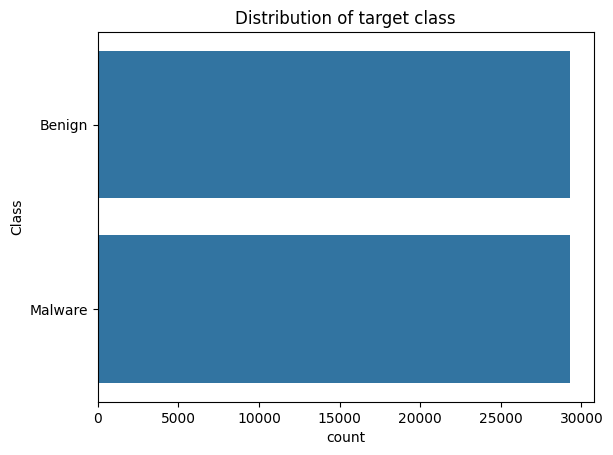

In [ ]:
sns.countplot(data["Class"])
plt.title("Distribution of target class")
plt.show()

In [ ]:
# checking for missing values
data.isna().sum()

,0
Category,0
pslist.nproc,0
pslist.nppid,0
pslist.avg_threads,0
pslist.nprocs64bit,0
pslist.avg_handlers,0
dlllist.ndlls,0
dlllist.avg_dlls_per_proc,0
handles.nhandles,0
handles.avg_handles_per_proc,0


In [ ]:
data.dtypes
# int64---100mb
# int32--- 60mb
# int16
# Quantization---64--32-16--8--4--1.58

,0
Category,object
pslist.nproc,int64
pslist.nppid,int64
pslist.avg_threads,float64
pslist.nprocs64bit,int64
pslist.avg_handlers,float64
dlllist.ndlls,int64
dlllist.avg_dlls_per_proc,float64
handles.nhandles,int64
handles.avg_handles_per_proc,float64


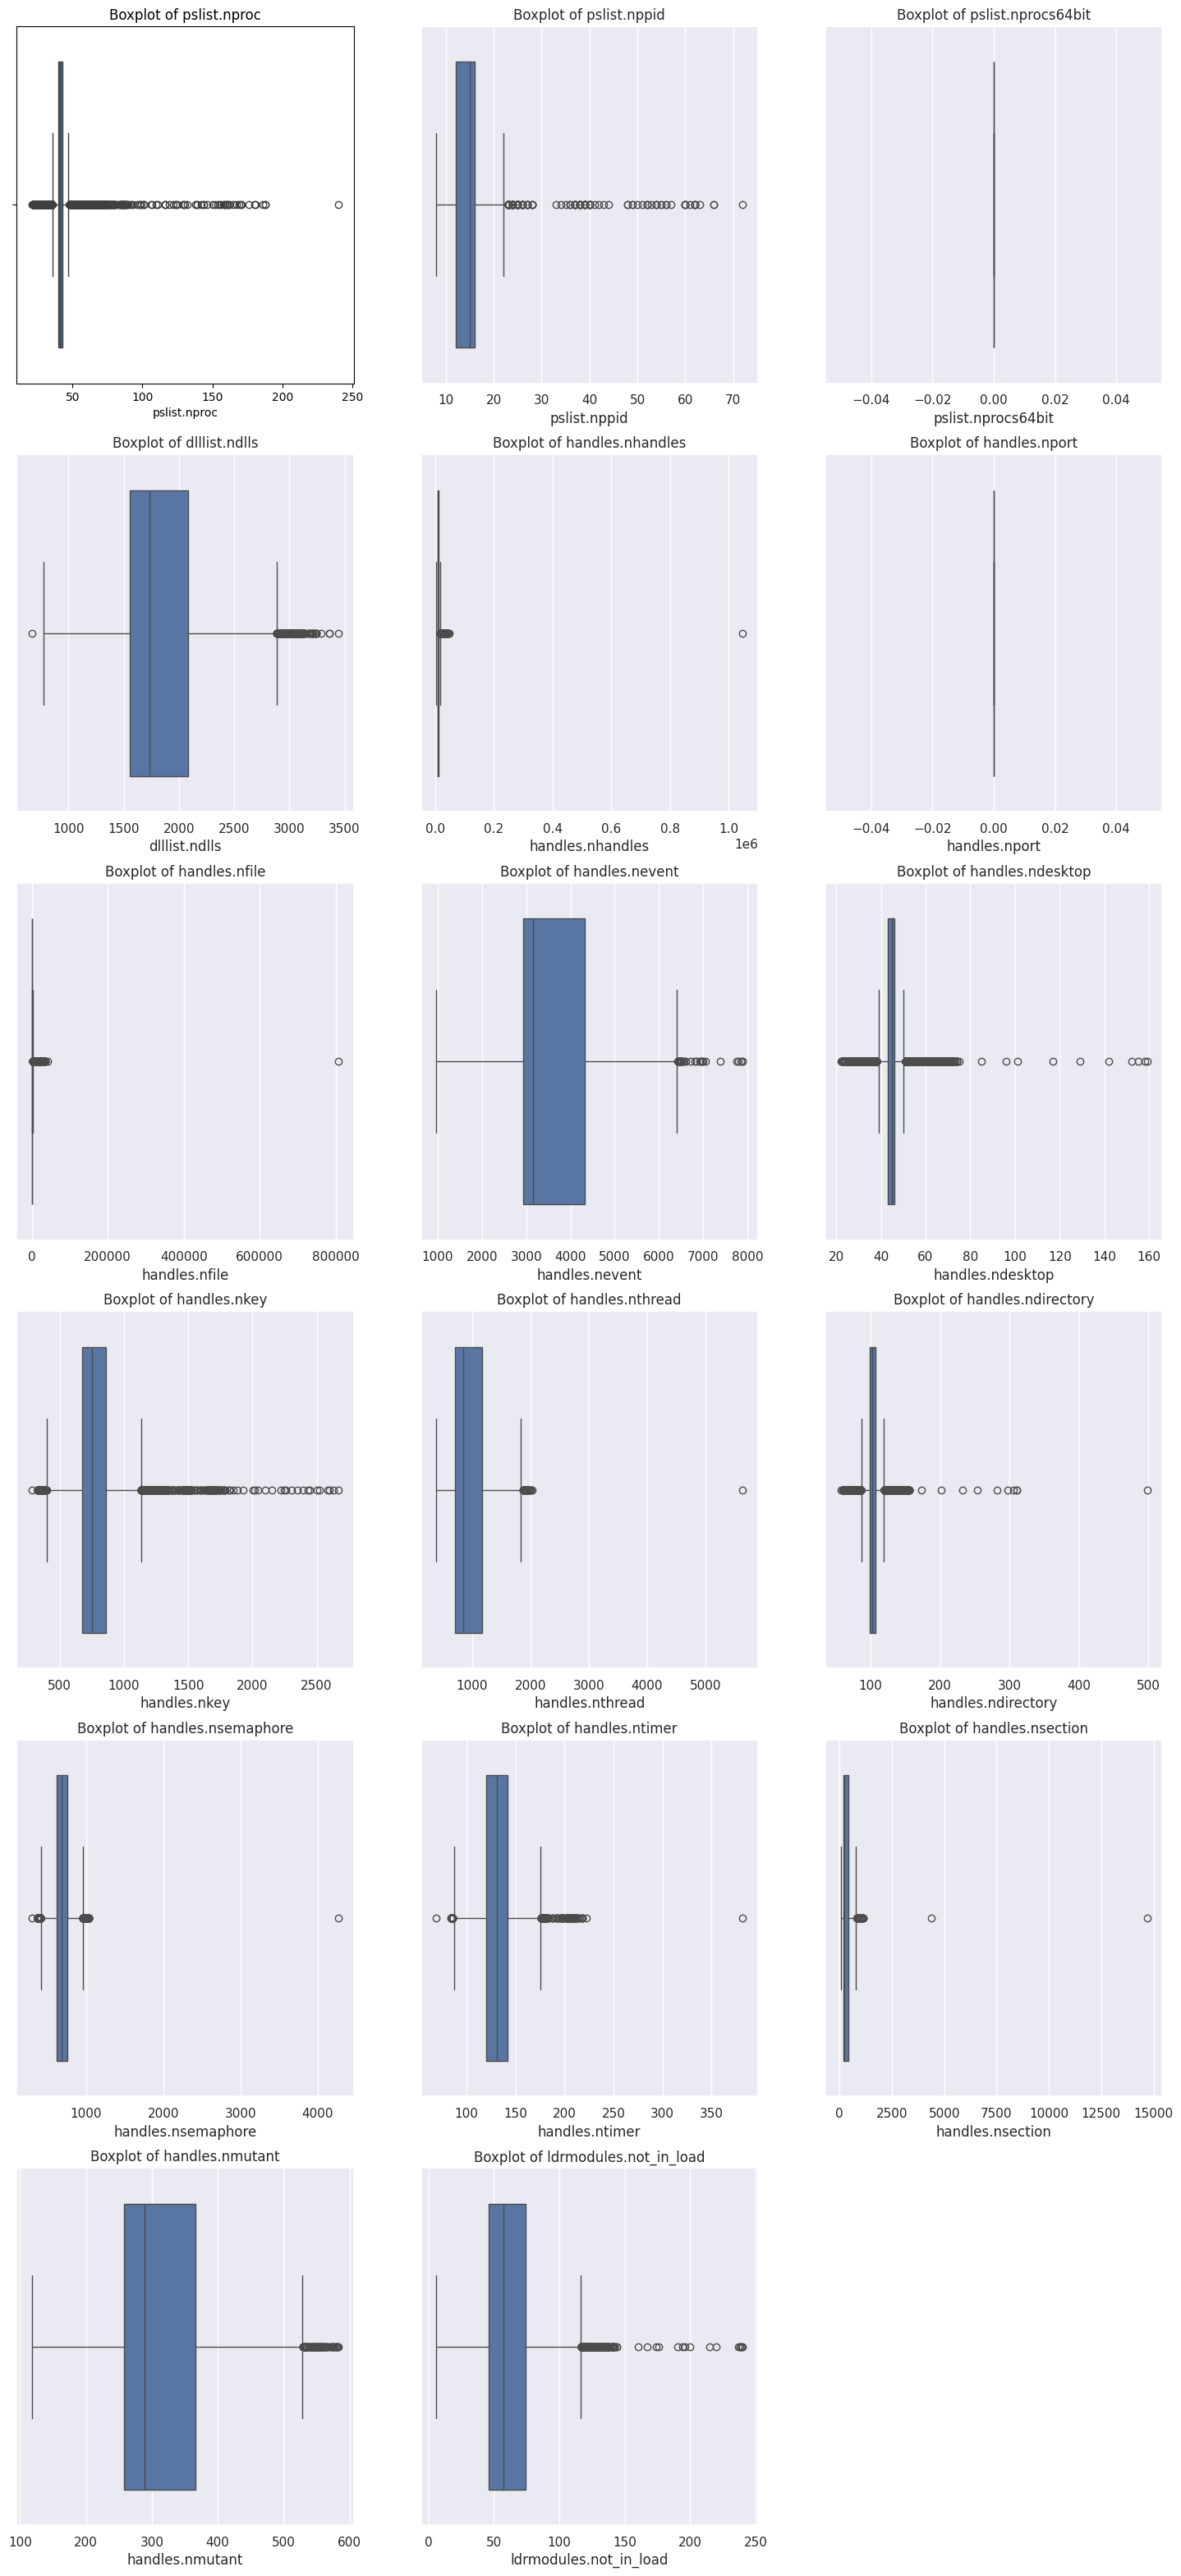

In [ ]:
num_cols=data.select_dtypes(include=int) # np.number(int and float)

plt.figure(figsize=(18,18))


for i,j in zip(range(1, 18),num_cols):
    plt.subplot(6, 3, i)
    plt.subplots_adjust(right=0.9,top=1.8)
    sns.boxplot(data=data, x=j)
    sns.set_theme()
    plt.title('Boxplot of {}'.format(j))

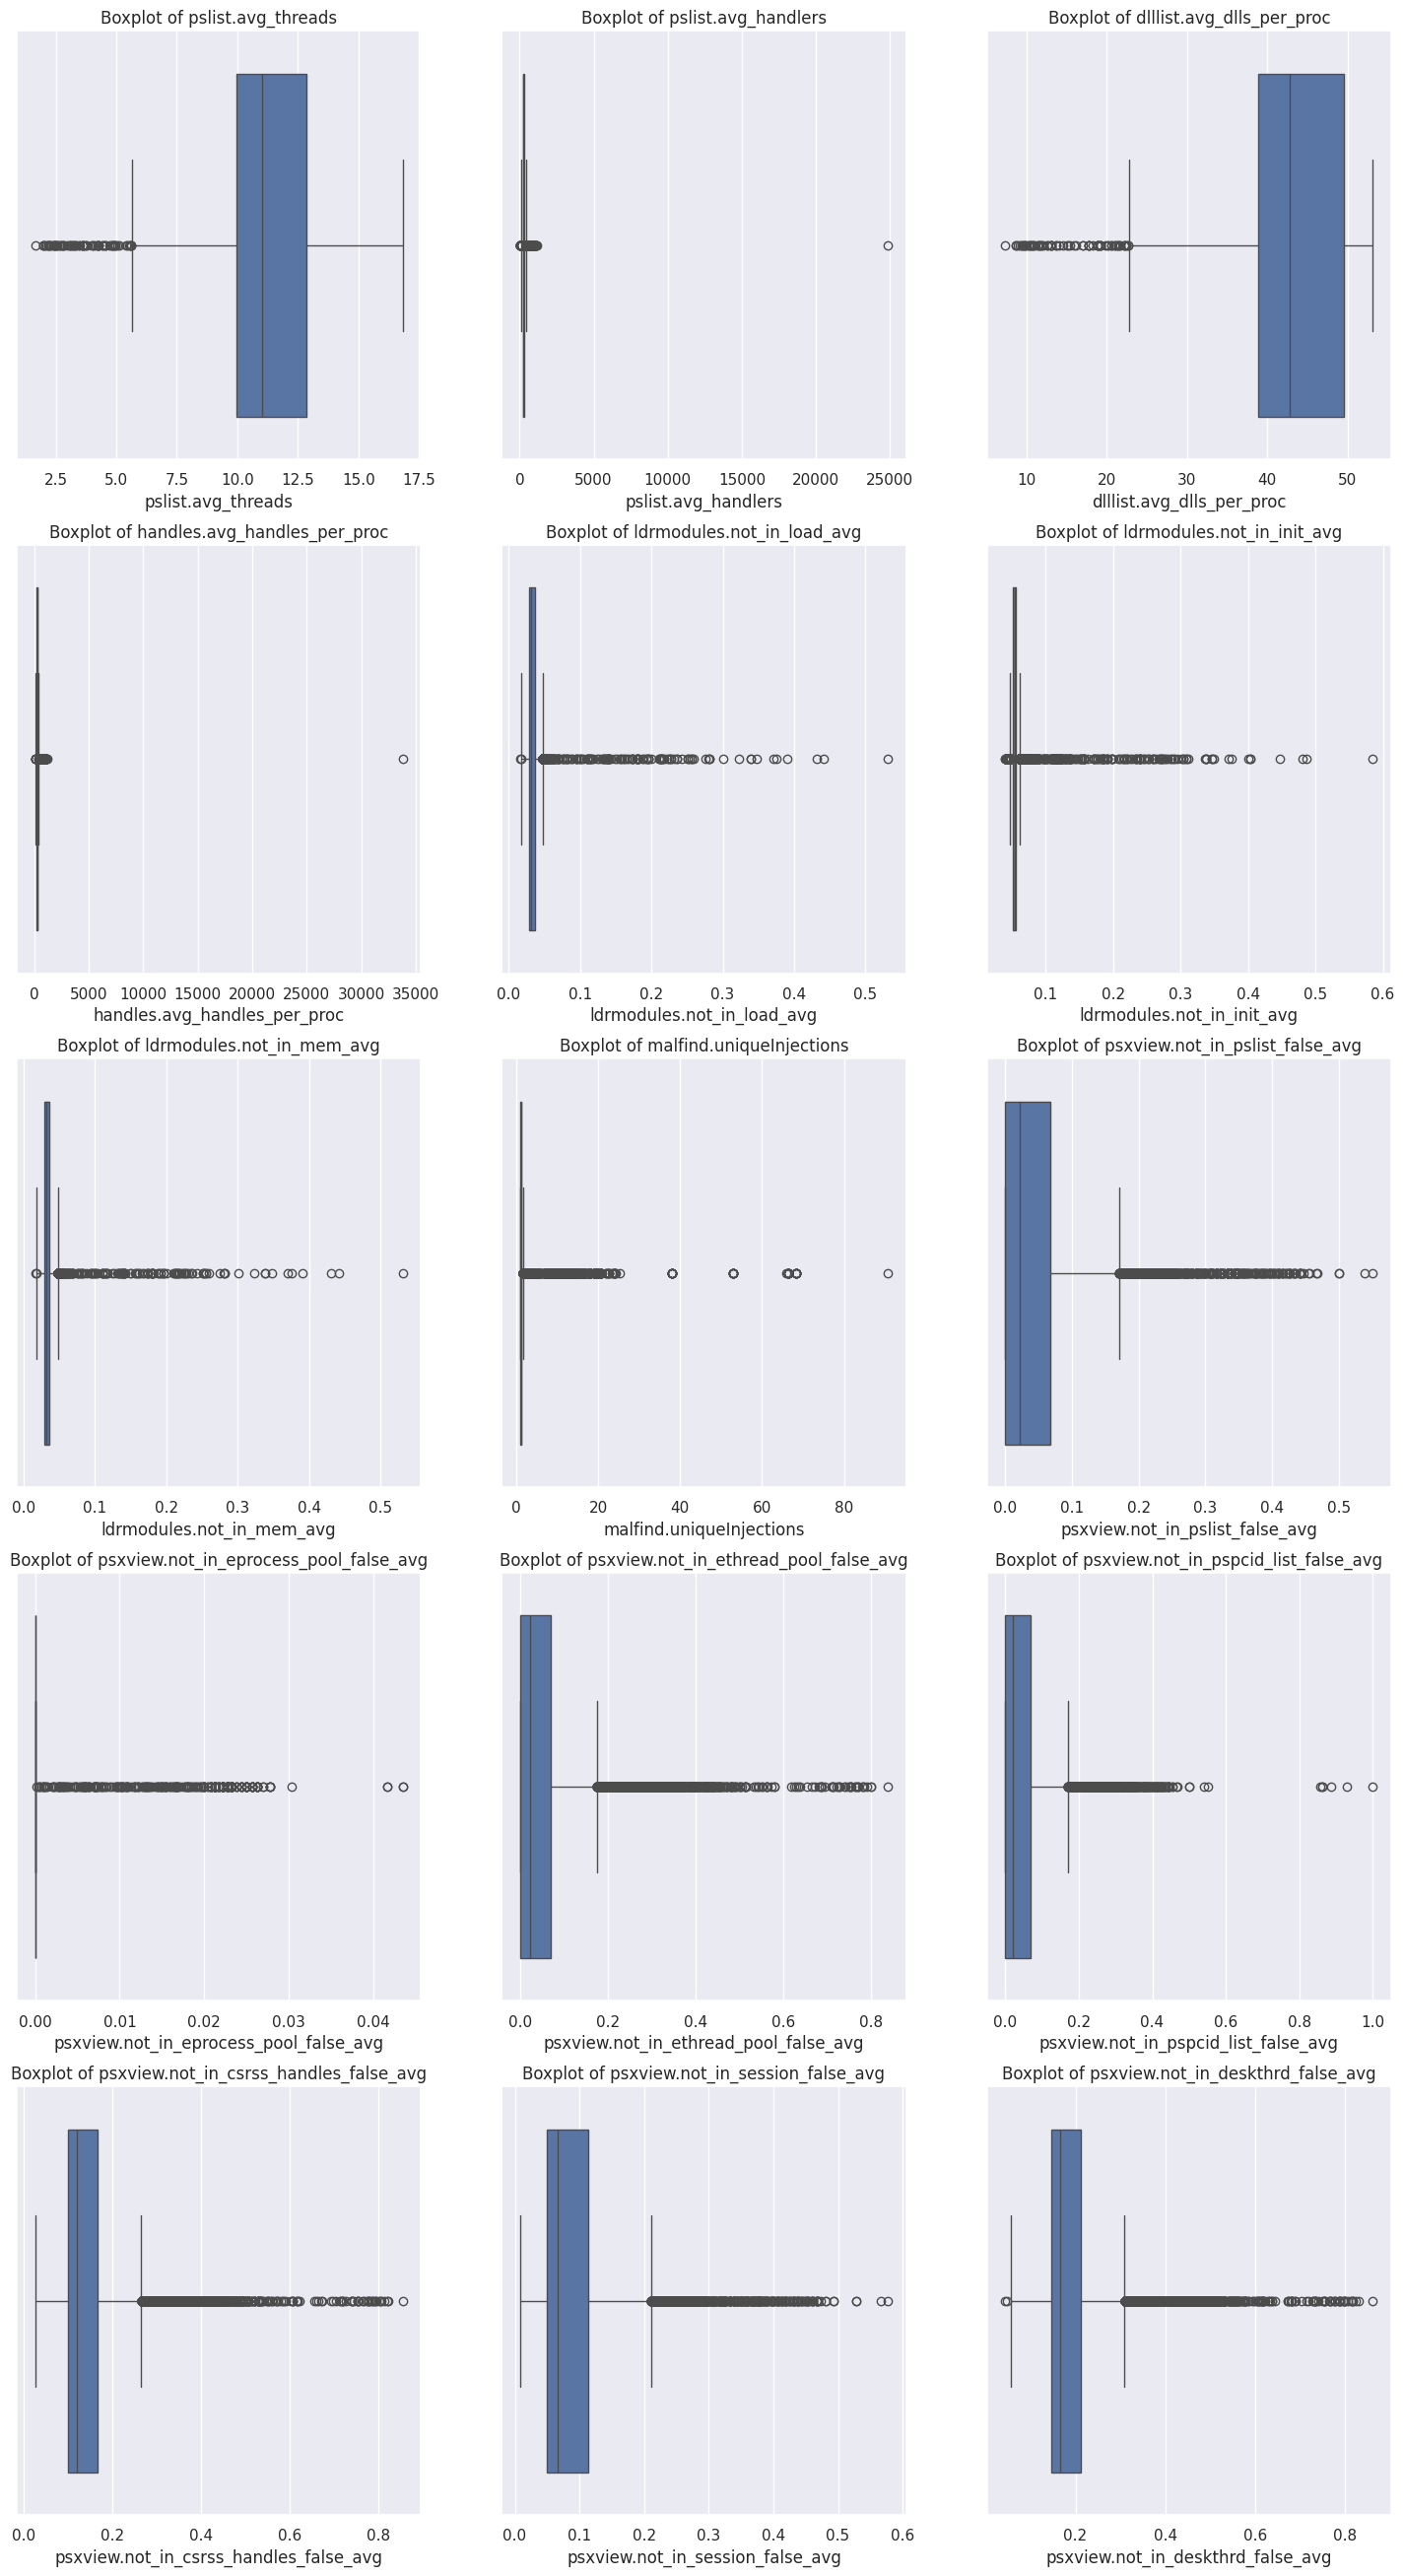

In [ ]:
float_cols=data.select_dtypes(include=float)

plt.figure(figsize=(18,18))
for i,j in zip(range(1, 18),float_cols):
    plt.subplot(6, 3, i)
    plt.subplots_adjust(right=0.9,top=1.8)
    sns.boxplot(data=data, x=j)
    sns.set_theme()
    plt.title('Boxplot of {}'.format(j))

In [ ]:
data["pslist.nprocs64bit"].nunique() # low cardinality column

1

In [ ]:
cardinality = data.nunique()

# Find columns with only 1 unique value
single_value_cols = cardinality[cardinality == 1].index.tolist()

print("Columns with only 1 unique value:")
print(single_value_cols)

Columns with only 1 unique value:
['pslist.nprocs64bit', 'handles.nport', 'svcscan.interactive_process_services']


In [ ]:
data_cleaned = data.drop(columns=single_value_cols)

print("\nShape before:", data.shape)
print("Shape after:", data_cleaned.shape)


Shape before: (58596, 57)
Shape after: (58596, 54)


In [ ]:
threshold = 0.95
high_card_cols = cardinality[cardinality / len(data) > threshold].index.tolist()

print("Low cardinality columns (1 unique):", single_value_cols)
print("High cardinality columns (>95% unique):", high_card_cols)


Low cardinality columns (1 unique): ['pslist.nprocs64bit', 'handles.nport', 'svcscan.interactive_process_services']
High cardinality columns (>95% unique): []


In [ ]:
# Checking for duplicate values in the dataset
print(len(data_cleaned[data_cleaned.duplicated()]))

534


In [ ]:
data_cleaned=data_cleaned.drop_duplicates()

In [ ]:
num_cols=data_cleaned.select_dtypes(include=np.number) # np.number(int and float)

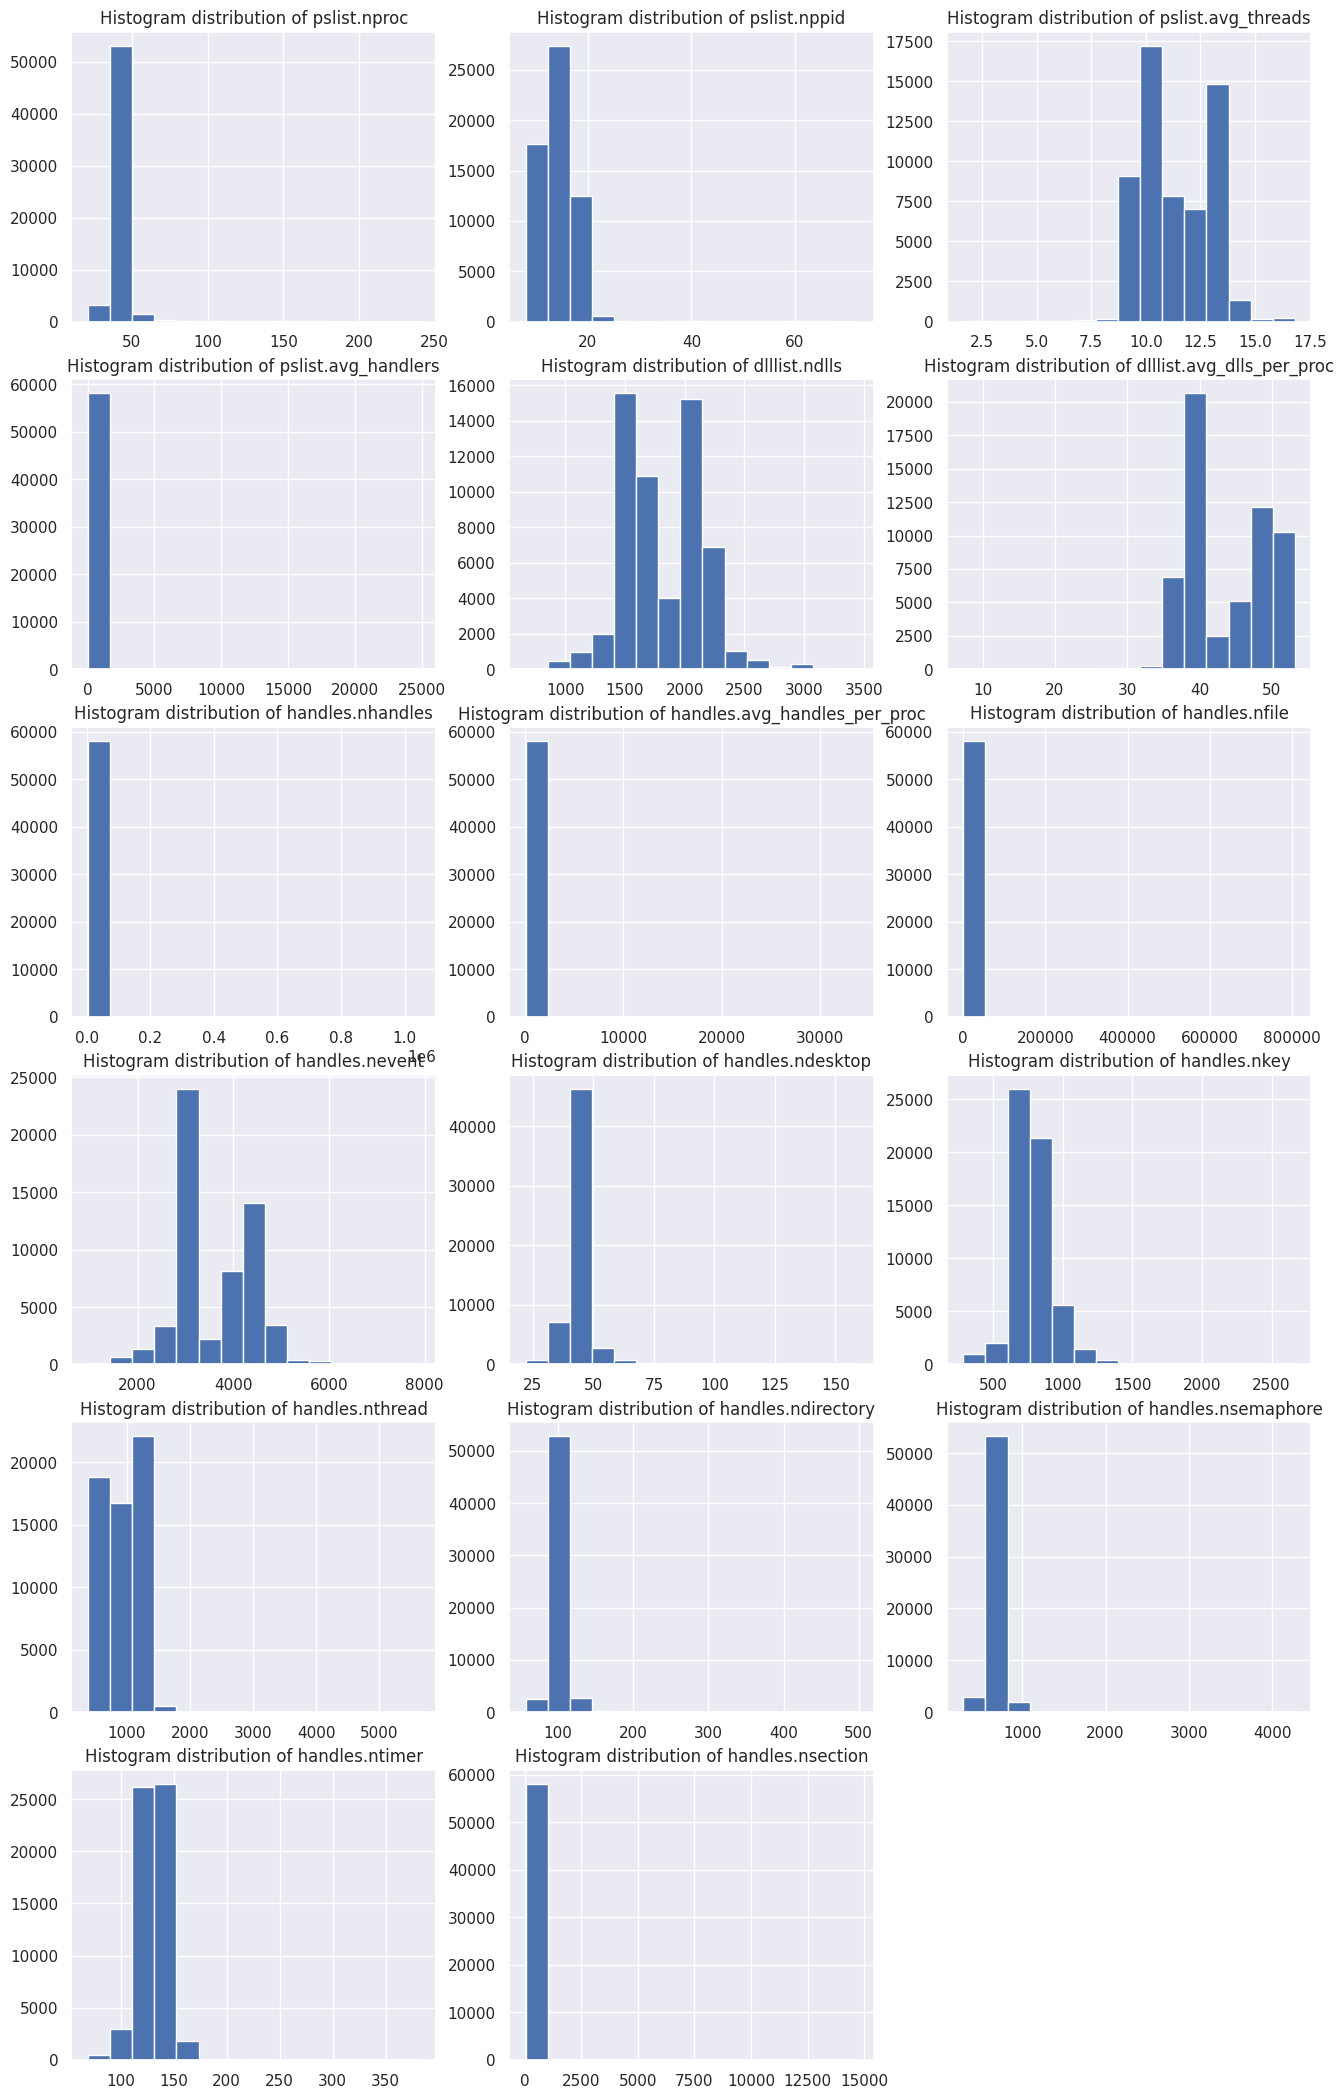

In [ ]:
plt.figure(figsize=(16,12))


for i,j in zip(range(1, 18),num_cols):
    plt.subplot(6, 3, i)
    plt.subplots_adjust(right=0.9,top=1.8)
    plt.hist(data_cleaned[j], bins = 15)
    sns.set_theme()
    plt.title('Histogram distribution of {}'.format(j))

plt.savefig('Histogram.png')

# Label encoding

In [ ]:
for col in data_cleaned.columns:
    if(data_cleaned[col].dtype == 'object'):
        data_cleaned[col]= data_cleaned[col].astype('category')
        data_cleaned[col] = data_cleaned[col].cat.codes



In [ ]:
data_cleaned.dtypes

,0
Category,int16
pslist.nproc,int64
pslist.nppid,int64
pslist.avg_threads,float64
pslist.avg_handlers,float64
dlllist.ndlls,int64
dlllist.avg_dlls_per_proc,float64
handles.nhandles,int64
handles.avg_handles_per_proc,float64
handles.nfile,int64


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, classification_report,confusion_matrix
# evaluate our classification problem
# f1 score when the target column is imbalanced in nature

In [ ]:
y_new=data_cleaned['Class'] # target variable
X_new=data_cleaned.drop(labels=['Class'], axis=1) # input feature

In [ ]:
'''
from sklearn.model_selection import train_test_split

# Assume X = features, y = labels

# Step 1: Split into 70% train and 30% temp (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y  # remove this if not doing classification
)

# Step 2: Split the 30% temp into 20% validation and 10% test
# Since temp is 30% of total,
# test should be 10/30 = 0.3333 of temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=1/3,
    random_state=42,
    stratify=y_temp  # remove if not classification
)

# Check proportions
print(len(X_train), len(X_val), len(X_test))
'''

'\nfrom sklearn.model_selection import train_test_split\n\n# Assume X = features, y = labels\n\n# Step 1: Split into 70% train and 30% temp (validation + test)\nX_train, X_temp, y_train, y_temp = train_test_split(\n    X, y,\n    test_size=0.3,\n    random_state=42,\n    stratify=y  # remove this if not doing classification\n)\n\n# Step 2: Split the 30% temp into 20% validation and 10% test\n# Since temp is 30% of total,\n# test should be 10/30 = 0.3333 of temp\nX_val, X_test, y_val, y_test = train_test_split(\n    X_temp, y_temp,\n    test_size=1/3,\n    random_state=42,\n    stratify=y_temp  # remove if not classification\n)\n\n# Check proportions\nprint(len(X_train), len(X_val), len(X_test))\n'

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size = 0.2, random_state = 42)



# Feature Scaling (so that we dont have to do any large calculation)
from sklearn.preprocessing import StandardScaler  # (-1,1) (to make the calculation easier)
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

'''
# Q1- what is the difference between fit _transform and transform

Fit → learns the parameters/statistics from the data.
Transform → uses those learned parameters to transform the data

2. transform()

transform() does NOT learn anything new.

It takes the parameters already learned during fit() and applies them to new data.

'''

In [ ]:
X_train

array([[ 1.56043235, -0.23943958,  0.47910084, ...,  0.02575253,
        -0.03008381,  0.01227704],
       [ 0.02864603,  1.44794631,  2.71218043, ..., -0.29903146,
        -0.03008381,  0.01227704],
       [-0.72969545, -0.23943958,  0.47910084, ..., -0.29903146,
        -0.03008381,  0.01227704],
       ...,
       [-0.7730355 ,  0.43551477,  1.2234607 , ...,  0.02575253,
        -0.03008381,  0.01227704],
       [-0.7730355 ,  0.0980376 , -1.00961889, ...,  0.35053653,
        -0.03008381,  0.01227704],
       [ 0.03849605,  0.60425336,  1.2234607 , ...,  0.35053653,
        -0.03008381,  0.01227704]])

In [ ]:
import joblib

joblib.dump(sc, "scaler.pkl")

print("✅ scaler.pkl saved successfully")

✅ scaler.pkl saved successfully


# Neural_network

In [ ]:
import keras
import tensorflow as tf # used for building industry level application (backend is written in keras)
# pytorch (research oriented)

# flattening--- convert your 2d matrix into 1d

model = keras.Sequential([ # sequential help us to initialize our neural network
                          keras.layers.Flatten(input_shape=(53,)), #input layer
                          keras.layers.Dense(16, activation=tf.nn.relu), #hidden layer
                          #keras.layer.Dropout(0.25),
   	                      keras.layers.Dense(16, activation=tf.nn.relu), # second hidden layer
                          keras.layers.Dense(1, activation=tf.nn.sigmoid), #output layer
]) # 2-tf.nn.softmax- for multiclass

# no of neurons-- 8,16,32,64,128,256,512,1024,2048

In [ ]:
model.summary()
# Parameters=(Input Units×Output Units)+Bias Terms

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 53)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,153 (4.50 KB)

 Non-trainable params: 0 (0.00 B)

An optimizer in a neural network is an algorithm that updates the weights of a neural network during training. The goal of an optimizer is to find the best weights that minimize the loss function.


In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# ============================================================
# 1. COMPILE THE MODEL
# ============================================================

model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# ============================================================
# 2. CALLBACKS
# ============================================================

# Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',          # Monitor validation loss
    patience=5,                  # Wait 5 epochs without improvement
    min_delta=0.001,             # Minimum improvement required
    mode='min',                  # Lower validation loss is better
    restore_best_weights=True,   # Restore weights from best epoch
    verbose=1
)


# Model Checkpoint
model_checkpoint = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',
    mode='min',
    save_best_only=True,         # Save only the best model
    save_weights_only=False,
    verbose=1
)


# Reduce Learning Rate when validation loss stops improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,                  # Reduce LR by 50%
    patience=2,                  # Wait 2 epochs
    min_lr=1e-6,                 # Don't go below this
    mode='min',
    verbose=1
)


# ============================================================
# 3. TRAIN THE MODEL
# ============================================================

history = model.fit(
    X_train,y_train,
    epochs=50,                   # Maximum number of epochs
    batch_size=32,
    validation_split=0.10,       # 10% of training data for validation
    callbacks=[
        early_stopping,
        model_checkpoint,
        reduce_lr
    ],
    verbose=1 # displaying u the output
)

Epoch 1/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9999 - loss: 5.7500e-04 - val_accuracy: 1.0000 - val_loss: 3.4898e-10
Epoch 2/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 1.0000 - loss: 1.3978e-07 - val_accuracy: 1.0000 - val_loss: 2.1952e-10
Epoch 3/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 1.0000 - loss: 8.0731e-08 - val_accuracy: 1.0000 - val_loss: 1.3662e-10
Epoch 4/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 1.0000 - loss: 3.8736e-08 - val_accuracy: 1.0000 - val_loss: 9.9256e-11
Epoch 5/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 1.0000 - loss: 2.2668e-08 - val_accuracy: 1.0000 - val_loss: 3.3252e-10
Epoch 6/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 1.0000 - loss: 1.2715e-08 - val_accuracy: 1.0000 - val_loss: 1.8161e-10
Epoch 7/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 1.0000 - loss: 8.2120e-09 - val_accuracy: 1.0000 - val_loss: 1.7074e-11
Epoch 8/10
1307/1307 ━━━━━━━━━━━━

In [ ]:
model.save('model.h5') # to use it in the API developmenet

# we use features pickel file
# we use weights file in the API development

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)

363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 3.1599e-09


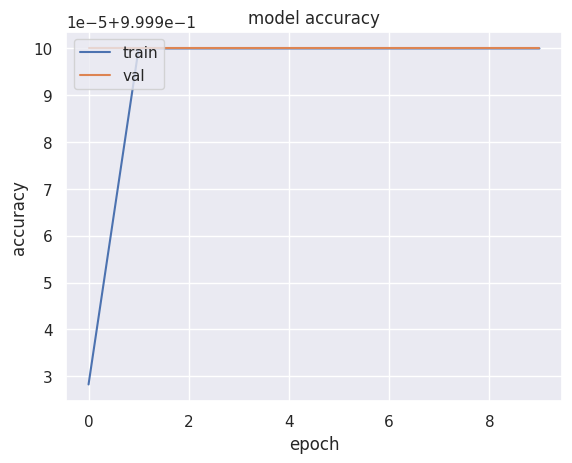

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])


plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

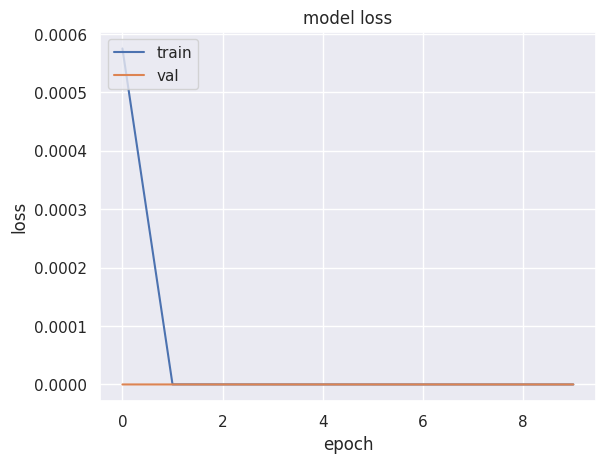

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])


plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
y_pred=model.predict(X_test)


class_names = ['malware', 'benign']


print(classification_report(y_test,np.rint(y_pred), target_names=class_names))

363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

     malware       1.00      1.00      1.00      5804
      benign       1.00      1.00      1.00      5809

    accuracy                           1.00     11613
   macro avg       1.00      1.00      1.00     11613
weighted avg       1.00      1.00      1.00     11613



# Project

https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification